# Human in the Loop

In [ ]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance langchain_openrouter typing-extensions

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 38.2 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")

In [ ]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="openai/gpt-oss-20b:free",
#     temperature=0.8,
# )


In [ ]:
from typing import Annotated
import operator, json
from typing import TypedDict, Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/tmp/ipykernel_1367/703281751.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [ ]:
llm.invoke("hi")

AIMessage(content='Hello! How are you today? Is there something I can help you with, or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 11, 'total_tokens': 35, 'completion_time': 0.054116085, 'completion_tokens_details': None, 'prompt_time': 0.000214157, 'prompt_tokens_details': None, 'queue_time': 0.481913777, 'total_time': 0.054330242}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f08cd12a81', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e62c3-b3a1-7922-9ae1-8cd41491403c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 24, 'total_tokens': 35})

In [ ]:
llm.invoke("hi").content

'How can I assist you today?'

In [ ]:
@tool
def multiply(first_number: int, second_number: int) -> int:
  """Multiply two integer numbers"""
  return first_number * second_number

In [ ]:
multiply(first_number=24, second_number=364)

TypeError: 'StructuredTool' object is not callable

In [ ]:
multiply.invoke({"first_number": 24, "second_number": 364})

8736

In [ ]:


@tool
def search(query:str):
  """Perform the web search for the user query"""
  tavily = TavilySearchResults()
  result = tavily.invoke(query)
  return result

In [ ]:
search.invoke({"query":"Whot is the current President of Iran?"})

[{'title': 'List of Presidents of Iran | Leaders, How Many, & Heads of State | Britannica',
  'url': 'https://www.britannica.com/topic/List-of-Presidents-of-Iran',
  'content': "| Masoud Pezeshkian - photographed in an undated handout image. Newly elected President of Iran Pezeshkian won the runoff in the Iran presidential election onJuly 6, 2024. | Masoud Pezeshkian | 2024– | Pezeshkian was elected to replace Raisi. He represented a major change in the office as a political centrist, becoming the most reform-oriented president since Khatami. The fact that he was even allowed to run in the 2024 election was interpreted by some observers as an attempt by the embattled regime to restore Iranians’ confidence in elections. But the conservative makeup of the government and his loyalty to the supreme leader left little hope for significant change. During the election campaign, Pezeshkian emphasized his intention to return to a nuclear deal with the West, but conflict [...] Iranian reformist 

In [ ]:
tools = [search, multiply]

In [ ]:
model_with_tools = llm.bind_tools(tools)

In [ ]:
tool_mapping = {tool.name: tool for tool in tools}

In [ ]:
tool_mapping

{'search': StructuredTool(name='search', description='Perform the web search for the user query', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x795710249260>),
 'multiply': StructuredTool(name='multiply', description='multiply two integer number', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x7957119ffa60>)}

In [ ]:
response = model_with_tools.invoke("Whot is the current President of Iran?")

In [ ]:
response

AIMessage(content="I don't have access to current President of Iran information. However, I can search for that information. \n\n", additional_kwargs={'tool_calls': [{'id': 'nxdcx124q', 'function': {'arguments': '{"query":"current President of Iran"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 759, 'total_tokens': 811, 'completion_time': 0.118123913, 'completion_tokens_details': None, 'prompt_time': 0.035276572, 'prompt_tokens_details': None, 'queue_time': 0.45904019, 'total_time': 0.153400485}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_5bd1e7ad73', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e62ce-b3dc-7130-92ef-ca4e719ec4ef-0', tool_calls=[{'name': 'search', 'args': {'query': 'current President of Iran'}, 'id': 'nxdcx124q', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [ ]:
tool_details = response.additional_kwargs.get("tool_calls")

In [ ]:
tool_details

[{'id': 'nxdcx124q',
  'function': {'arguments': '{"query":"current President of Iran"}',
   'name': 'search'},
  'type': 'function'}]

In [ ]:
tool_details[0]["function"]["name"]

'search'

In [ ]:
tool_details[0]["function"]["arguments"]

'{"query":"current President of Iran"}'

In [ ]:
json.loads(tool_details[0]["function"]["arguments"])

{'query': 'current President of Iran'}

In [ ]:
tool_mapping[tool_details[0]["function"]["name"]].invoke(json.loads(tool_details[0]["function"]["arguments"]))

[{'title': 'President of Iran - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/President_of_Iran',
  'content': 'The president is elected for a four-year term in a national election by universal adult suffrage by Iranians of at least 18 years of age, and can only be reelected once if in a consecutive manner. Candidates for the presidency must be approved by the Guardian Council. Masoud Pezeshkian is currently the president of Iran, after being elected in the 2024 Iranian presidential election and being officially endorsed by the supreme leader.\n\n## History\n\n| Politics of Iran | [...] | President of the Islamic Republic of Iran | |\n --- |\n| رئیس جمهور ایران (Persian) | |\n| Emblem | |\n| Flag of Iran | |\n| Incumbent Masoud Pezeshkian since 28 July 2024 | |\n| Presidential Administration | |\n| Style "Style (form of address)") | Mr. President "President (government title)") |\n| Type | Head of state Head of government Acting Head of the Executive Branch Deputy Commander-in-Ch

In [ ]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], operator.add]

In [ ]:
def invoke_model(state: AgentState):
  messages = state["messages"]
  question = messages[-1] # Fetching the user question
  return {"messages": [model_with_tools.invoke(question)]}

In [ ]:
def invoke_tool(state: AgentState):
  tool_details = state["messages"][-1].additional_kwargs.get("tool_calls", [])[0]

  if tool_details is None:
    raise Exception("Not tool call found")

  print(f'Selected tool: {tool_details.get("function").get("name")}')

  if tool_details.get("function").get("name") == "search":
    response = input(prompt=f"[y/n] continue with expensive web search?")
    if response == "n":
      raise Exception("web search is discarded")


  response = tool_mapping[tool_details['function']['name']].invoke(json.loads(tool_details.get("function").get("arguments")))
  return {"messages": [response]}


In [ ]:
def router(state):
  tool_calls = state["messages"][-1].additional_kwargs.get("tool_calls", [])
  if len(tool_calls):
    return "tool"
  else:
    return "end"

In [ ]:
graph = StateGraph(AgentState) # StateGraph with AgentState

graph.add_node("ai_assistant", invoke_model)

graph.add_node("tool", invoke_tool)

In [ ]:
graph.set_entry_point("ai_assistant")

graph.add_conditional_edges("ai_assistant", router, {"tool": "tool", "end": END})

# graph.add_edge("tool", "ai_assistant")

graph.add_edge("tool", END)

In [ ]:
app = graph.compile()

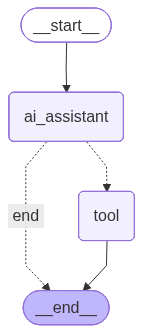

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
for s in app.stream({"messages": ["Who is the current President of China?"]}):
  print(list(s.values())[0])
  print("-----------")

{'messages': [AIMessage(content="I don't have access to search information.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 758, 'total_tokens': 767, 'completion_time': 0.020314631, 'completion_tokens_details': None, 'prompt_time': 0.032996881, 'prompt_tokens_details': None, 'queue_time': 0.161634385, 'total_time': 0.053311512}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_5bd1e7ad73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e62dd-7e32-7833-8bba-fcb4d89835be-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 758, 'output_tokens': 9, 'total_tokens': 767})]}
-----------


In [ ]:
for s in app.stream({"messages": ["What is the Multiplication of 23 and 46?"]}):
  print(list(s.values())[0])
  print("-----------")

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'cdgshke9n', 'function': {'arguments': '{"first_number":23,"second_number":46}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 761, 'total_tokens': 798, 'completion_time': 0.083805228, 'completion_tokens_details': None, 'prompt_time': 0.042815959, 'prompt_tokens_details': None, 'queue_time': 0.09395343, 'total_time': 0.126621187}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_5bd1e7ad73', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e62dd-86cf-7033-857e-c17bc85e2a49-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': 23, 'second_number': 46}, 'id': 'cdgshke9n', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 761, 'output_tokens': 37, 'total_tokens': 798})]}
-----------
Selected tool: m

In [ ]:
for s in app.stream({"messages": ["What is the total amount of money exist over the Earth?"]}):
  print(list(s.values())[0])
  print("-----------")

{'messages': [AIMessage(content="I don't have access to the exact figure representing the total amount of money that exists over the Earth. However, I can tell you that estimating the total amount of money in the world is a complex task, as it involves considering various forms of currency, including physical cash, digital payments, and investments. \n\nIf you need an approximate figure, I can suggest some publicly available sources that provide estimates of the global money supply. Would you like me to search for this information? \n\nIf yes, then:", additional_kwargs={'tool_calls': [{'id': '802dq1d5p', 'function': {'arguments': '{"query":"total amount of money in the world"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 762, 'total_tokens': 896, 'completion_time': 0.30258302, 'completion_tokens_details': None, 'prompt_time': 0.030190709, 'prompt_tokens_details': None, 'queue_time': 0.12783363, 'total_time': 0

#### LangGraph supports human-in-the-loop workflows in a number of ways. In this section, we will use LangGraph's interrupt_before functionality to always break the tool node.

In [ ]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="openai/gpt-oss-20b:free",
#     temperature=0.8,
# )

In [ ]:
class AgentState(TypedDict):
  messages: Annotated[list, add_messages]

In [ ]:
tavily = TavilySearchResults()

In [ ]:
tools = [tavily]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [ ]:
def ai_assistant(state: AgentState):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [ ]:
memory = MemorySaver()

In [ ]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node("ai_assistant", ai_assistant)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [ ]:
graph_builder.add_edge(START, "ai_assistant")

graph_builder.add_conditional_edges(
    "ai_assistant",
    tools_condition,

)

graph_builder.add_edge("tools", "ai_assistant")

In [ ]:
app2 = graph_builder.compile(
    checkpointer = memory,
    # This is new
    interrupt_before=["tools"],
    # Note: can also interrupt __after__ tools, if you like.
    # interrupt_after=["tools"]
)

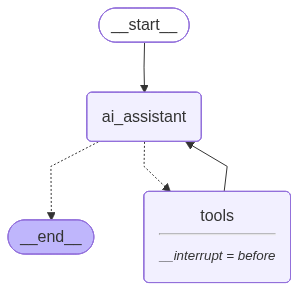

In [ ]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [ ]:
user_input = "What is a current capital of China?"
config = {"configurable": {"thread_id": "1"}}

In [ ]:
# The config is the **second positional argument** to stream() or invoke()!
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [ ]:
for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is a current capital of China?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (7vmnfzw1v)
 Call ID: 7vmnfzw1v
  Args:
    query: current capital of China


In [ ]:
snapshot = app2.get_state(config)

In [ ]:
snapshot.next

('tools',)

In [ ]:
last_message = snapshot.values["messages"][-1]

In [ ]:
# `None` will append nothing new to the current state, letting it resume as if it had never been interrupted
events = app2.stream(None, config, stream_mode="values")

In [ ]:
for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (7vmnfzw1v)
 Call ID: 7vmnfzw1v
  Args:
    query: current capital of China
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Beijing, China | Geography and Cartography | Research Starters | EBSCO Research", "url": "https://www.ebsco.com/research-starters/geography-and-cartography/beijing-china", "content": "# Beijing, China\n\nBeijing, the capital of the People's Republic of China, is one of the world's oldest cities, with a history of habitation exceeding four thousand years. Known as the \"Northern Capital,\" it has served as the seat of power for various Chinese dynasties. Located in northeastern China, Beijing Municipality covers 17,000 square kilometers and features a mix of historical landmarks and modern infrastructure. The city is densely populated, with an urban population of over

In [ ]:
user_input = "What is a weather in there?"
config = {"configurable": {"thread_id": "1"}}

In [ ]:
# The config is the **second positional argument** to stream() or invoke()!

In [ ]:
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [ ]:
for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is a weather in there?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (5nht227dt)
 Call ID: 5nht227dt
  Args:
    query: Beijing weather


In [ ]:
snapshot = app2.get_state(config)

In [ ]:
snapshot.next

('tools',)

In [ ]:
last_message = snapshot.values["messages"][-1]

In [ ]:
last_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Beijing weather'},
  'id': '5nht227dt',
  'type': 'tool_call'}]

In [ ]:
# `None` will append nothing new to the current state, letting it resume as if it had never been interrupted
events = app2.stream(None, config, stream_mode="values")

In [ ]:
for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (5nht227dt)
 Call ID: 5nht227dt
  Args:
    query: Beijing weather
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Beijing Weather Conditions: Temperature | 30 Days Forecast - AQI.in", "url": "https://www.aqi.in/weather/us/china/beijing/beijing", "content": "UV6.9\n\n## Beijing 30-Days (May 2026) Weather Forecast\n\nPartly Cloudy\nPatchy rain nearby\nSunny\nSunny\nSunny\nPartly Cloudy\nSunny\nSunny\nPartly Cloudy\nSunny\nPatchy rain nearby\nSunny\nSunny\nSunny\nSunny\nPatchy rain nearby\nHeavy Rain\nPatchy rain nearby\nPartly Cloudy\nPatchy rain nearby\nSunny\nHeavy Rain\nPartly Cloudy\nSunny\nPatchy rain nearby\nSunny\nSunny\nSunny\nSunny\nSunny\nSunny\n\n### MayWeather Overview\n\n|  | No. of days: |\n --- |\n| Sunny | 18 |\n| Cloudy | 5 |\n| Rainy | 8 |\n| Snowy | 0 |\n\n#### No. of da

In [ ]:
app2.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='What is a current capital of China?', additional_kwargs={}, response_metadata={}, id='5c14d7a4-351f-4efb-877d-c78369d72a48'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7vmnfzw1v', 'function': {'arguments': '{"query":"current capital of China"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 750, 'total_tokens': 786, 'completion_time': 0.081299905, 'completion_tokens_details': None, 'prompt_time': 0.044368535, 'prompt_tokens_details': None, 'queue_time': 0.049637151, 'total_time': 0.12566844}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_5bd1e7ad73', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e62e1-9957-70d2-b15c-cc04f181733e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'curr

In [ ]:
snapshot = app2.get_state(config)

In [ ]:
snapshot.next

()

In [ ]:
user_input = "Please provide me the recent news of it."
config = {"configurable": {"thread_id": "1"}}

In [ ]:
events = app2.stream({"messages": [("user", user_input)]}, config, stream_mode="values")

In [ ]:
for event in events:
  if "messages" in event:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Please provide me the recent news of it.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (hms2xmvtd)
 Call ID: hms2xmvtd
  Args:
    query: recent news Beijing


In [ ]:
snapshot = app2.get_state(config)

In [ ]:
snapshot.next

('tools',)

In [ ]:
current_message = snapshot.values["messages"][-1]

In [ ]:
current_message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (hms2xmvtd)
 Call ID: hms2xmvtd
  Args:
    query: recent news Beijing


In [ ]:
tool_call_id = current_message.tool_calls[0]["id"]

AttributeError: 'dict' object has no attribute 'id'

In [ ]:
tool_call_id

In [ ]:
from langchain_core.messages import AIMessage, ToolMessage

In [ ]:
answer = "It is just related to raining which is happening on daily basis"

In [ ]:
new_messages = [
    ToolMessage(content=answer, tool_call_id=tool_call_id),
    AIMessage(content=answer),
]

In [ ]:
app2.update_state(
    config,
    {"messages": new_messages},
)

In [ ]:
print(app2.get_state(config).values["messages"][-1:])